# CPSC 375 Classwork - Exploratory data analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ProfAvery/cpsc375-classwork/blob/main/eda.ipynb)

- *Manager*:
- *Recorder*:
- *Presenter*:
- *Timekeeper*:

*Note*: On Google Colab, run the following code cell to download the `cpsc375` module before trying to `import`:

In [1]:
!mkdir -p ./cpsc375 && wget --quiet --timestamping https://raw.githubusercontent.com/ProfAvery/cpsc375-classwork/refs/heads/main/cpsc375/__init__.py --output-document=./cpsc375/__init__.py

In [2]:
from cpsc375 import *

## Part 1 - Slide 15

Consider the data *iris*

1. Create a histogram of Sepal.Width


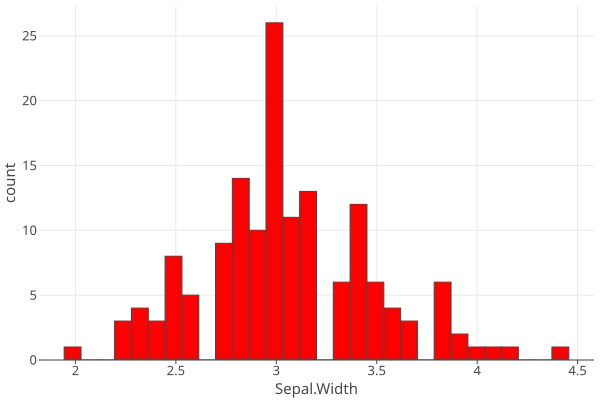

In [15]:
ggplot(data=iris) + geom_histogram((aes(x="Sepal.Width")), fill="red")

2. Try different numbers of bins

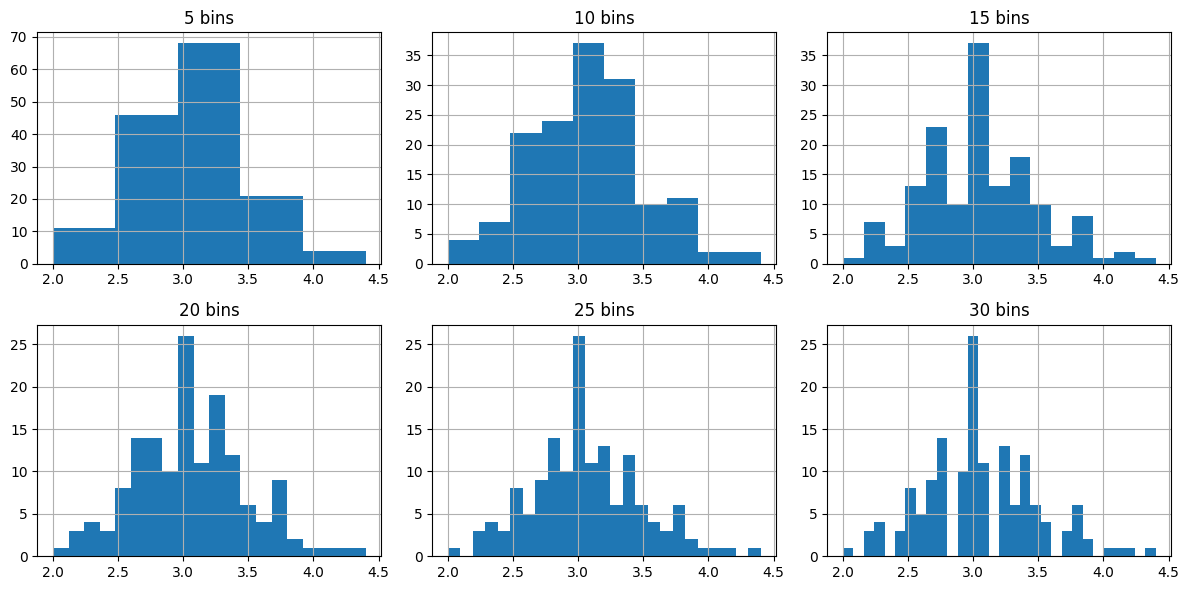

In [18]:
fig, axes = plt.subplots(2,3, figsize=(12,6))

for ax, i in zip(axes.flat, range(5,31, 5)):
  iris["Sepal.Width"].hist(bins=i, ax=ax)
  ax.set_title(f"{i} bins")

plt.tight_layout()
plt.show()

## Part 2 - Slide 28

* Construct a boxplot of the *Ozone* column of the *airquality* dataset

<Axes: >

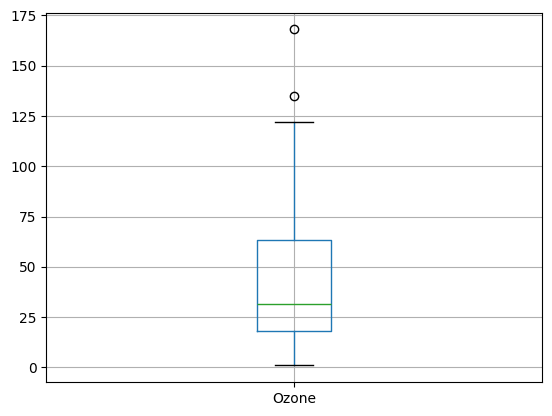

In [19]:
airquality.boxplot('Ozone')

Verify that the outliers match what you get using the IQR "rule-of-thumb"

*Hint*: use `scipy.stats.iqr` and/or `df.quantile` functions

In [20]:
IQR = 1.5 * (airquality.Ozone.quantile(0.75) - airquality.Ozone.quantile(0.25))
airquality.Ozone[(airquality.Ozone < airquality.Ozone.quantile(0.25) - IQR) | (airquality.Ozone > airquality.Ozone.quantile(0.75) + IQR)].count()

np.int64(2)

* Construct a boxplot of these 9 values
  
  8,11,17,36,25,24,1,20,64

sorted: [1, 8, 11, 17, 20, 24, 25, 36, 64]
Q1: 11.0
median: 20.0
Q3: 25.0
IQR: 14.0
fences: -10.0 46.0
whiskers end at: 1 36
outliers: [64]


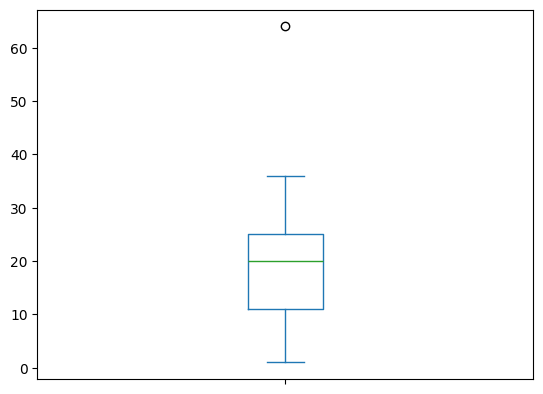

In [23]:
values = [8, 11, 17, 36, 25, 24, 1, 20, 64]
data = pd.Series(values)

Q1 = data.quantile(0.25)
median = data.median()
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = data[(data < lower_fence) | (data > upper_fence)]
inside = data[(data >= lower_fence) & (data <= upper_fence)]

print("sorted:", sorted(values))
print("Q1:", Q1)
print("median:", median)
print("Q3:", Q3)
print("IQR:", IQR)
print("fences:", lower_fence, upper_fence)
print("whiskers end at:", inside.min(), inside.max())
print("outliers:", list(outliers))

data.plot.box();

## Part 3 - Slide 30

Explore the *airquality* dataset

 * How many variables, size of the data, …
    - Is this Big Data?
   

In [29]:
airquality

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


 * Summary statistics


In [27]:
airquality.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


 * Is there missing data? Which variables are most affected?


In [30]:
airquality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


 * Visualize each variable individually
   - Are there outliers?
  

 * Should any variable(s) be converted to a categorical?
   - Which ones?


## Part 4 - Slide 40

 Explore the *airquality* dataset

 * Should any variable(s) be converted to a categorical?
   - Convert these to a categorical


 * Visualize any 5 pairs of variables of the airquality dataset
   - Choose the appropriate plot for each pair
   